In [32]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime

# 自作モジュールの読み込み
sys.path.append(os.path.abspath('..'))
from configs.config import *
from src.runner import Runner
from src.model_LGBM import model_LGBM
from src.util import Logger, Util

In [33]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# LGBM ユニバース分割

In [34]:
import importlib
from src import runner
from src import model_LGBM
from src import model
from configs import config

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)
importlib.reload(config)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import Runner
from src.model_LGBM import model_LGBM
from configs.config import *

In [35]:
# Key
df_all = Util.load_feature('Key')

# 目的変数
key_col = ['社員番号', 'category']
df_all = pd.merge(df_all, Util.load_feature('Target'), on=key_col, how='left')

# category特徴量
key_col = 'category'
list_feature_name = [
    'CategoryFeature',
]
for feature_name in list_feature_name:
    df_feature = Util.load_feature(feature_name)
    df_all = pd.merge(df_all, df_feature, on=key_col, how='left')

# 社員特徴量
key_col = '社員番号'
list_feature_name = [
    'CareerFeature',
    'DxFeature',
    'HrFeature',
    'OvertimeWorkByMonthFeature',
    'PositionHistoryFeature',
    'UdemyActivityFeature',
    'UdemyUserEmbedding',
]
for feature_name in list_feature_name:
    df_feature = Util.load_feature(feature_name)
    df_all = pd.merge(df_all, df_feature, on=key_col, how='left')

# train/test
df_train = df_all[df_all['target'].notnull()]
df_test = df_all[df_all['target'].isnull()]

print('train shape: {}'.format(df_train.shape))
print('test shape: {}'.format(df_test.shape))

train shape: (7338, 574)
test shape: (11022, 574)


In [36]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_unv")
run_name = 'lgbm_unv_202507311522'
run_name

'lgbm_unv_202507311522'

In [37]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
        target_col(str): 予測値のカラム名
    Returns:    
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    return df_pred

def after_split_process(tr, va):
    """データセットの分割後に行う処理
    Args:
        tr(pd.DataFrame): 訓練データ
        va(pd.DataFrame): 検証データ
    returns:
        tr(pd.DataFrame): 訓練データ
        va(pd.DataFrame): 検証データ
    """
    return tr, va

model_params_lgb = {
    #### run params
    "key_cols": KEY_COL,                    # ユニークキー
    "target_col": TARGET_COL,              # 目的変数（0 or 1）
    "remove_cols": [],
    #### model train params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": -1,
    "period": 100,
    "log_level": 'error',
    "verbosity": -1,
    #### model core params (for binary classification)
    # "scale_pos_weight": 10,
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'auc', # 'binary_logloss',
    'n_estimators': 10000,
    "max_depth": 15,
    "num_leaves": 500,
    'feature_fraction': 0.8,
    'bagging_freq': 1,
    'learning_rate': 0.01,
    'bagging_fraction': 0.8,
    'num_leaves': 6,
    'random_state': 42,
    "colsample_bytree": 0.9,
    "colsample_bynode": 0.6,
    "lambda_l1": 3.5,
    "lambda_l2": 1.5,
    "min_data_in_leaf": 50,
    'device':'cpu',
}

run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "after_predict_process": after_predict_process,
    'after_split_process': after_split_process,  
}
cv_setting = {
    "target_col": TARGET_COL,
    "group_col": "社員番号",  # グループ化するカラム
    "n_splits": 3,  # 分割数,
    "shuffle": True,  # シャッフルするか否か
    "random_state": 42,  # ランダムシード
}

In [38]:
memo = "LightGBM categoryでユニバース分割して学習"
ml_runner_content = Runner(
    f'{run_name}_content', model_LGBM, model_params_lgb,
    df_train[df_train['category']=='コンテンツ・サービス・デザイン'],
    df_test[df_test['category']=='コンテンツ・サービス・デザイン'],
    run_setting, cv_setting, logger, memo,
)
ml_runner_corp = Runner(
    f'{run_name}_corp', model_LGBM, model_params_lgb,
    df_train[df_train['category']=='コーポレート管理部門/技術・データ・BPR'],
    df_test[df_test['category']=='コーポレート管理部門/技術・データ・BPR'],
    run_setting, cv_setting, logger, memo,
)
ml_runner_product = Runner(
    f'{run_name}_product', model_LGBM, model_params_lgb,
    df_train[df_train['category']=='プロダクトマネジメント'],
    df_test[df_test['category']=='プロダクトマネジメント'],
    run_setting, cv_setting, logger, memo,
)
ml_runner_marketing = Runner(
    f'{run_name}_marketing', model_LGBM, model_params_lgb,
    df_train[df_train['category']=='マーケティング'],
    df_test[df_test['category']=='マーケティング'],
    run_setting, cv_setting, logger, memo,
)
ml_runner_dev = Runner(
    f'{run_name}_dev', model_LGBM, model_params_lgb,
    df_train[df_train['category']=='事業企画・開発・研究'],
    df_test[df_test['category']=='事業企画・開発・研究'],
    run_setting, cv_setting, logger, memo,
)
ml_runner_sales = Runner(
    f'{run_name}_sales', model_LGBM, model_params_lgb,
    df_train[df_train['category']=='営業'],
    df_test[df_test['category']=='営業'],
    run_setting, cv_setting, logger, memo,
)

In [39]:
# ml_runner.tune_params(30)

In [40]:
ml_runner_content.run_train_cv()
ml_runner_corp.run_train_cv()
ml_runner_product.run_train_cv()
ml_runner_marketing.run_train_cv()
ml_runner_dev.run_train_cv()
ml_runner_sales.run_train_cv()

[2025-07-31 16:34:37] - lgbm_unv_202507311522_content - start training cv
[2025-07-31 16:34:37] - lgbm_unv_202507311522_content fold 0 - start training
c:\Users\ishiz\anaconda3\envs\atma_udemy\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.942185	eval's auc: 0.651351
Early stopping, best iteration is:
[13]	train's auc: 0.913548	eval's auc: 0.726817


[2025-07-31 16:34:38] - lgbm_unv_202507311522_content fold 0 - end training
[2025-07-31 16:34:38] - lgbm_unv_202507311522_content fold 1 - start training
c:\Users\ishiz\anaconda3\envs\atma_udemy\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.947982	eval's auc: 0.676446
Early stopping, best iteration is:
[23]	train's auc: 0.923429	eval's auc: 0.710544


[2025-07-31 16:34:38] - lgbm_unv_202507311522_content fold 1 - end training
[2025-07-31 16:34:38] - lgbm_unv_202507311522_content fold 2 - start training
c:\Users\ishiz\anaconda3\envs\atma_udemy\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


...

[2025-07-31 16:34:50] - lgbm_unv_202507311522_sales fold 0 - end training
[2025-07-31 16:34:50] - lgbm_unv_202507311522_sales fold 1 - start training
c:\Users\ishiz\anaconda3\envs\atma_udemy\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.931103	eval's auc: 0.518797
Early stopping, best iteration is:
[12]	train's auc: 0.920821	eval's auc: 0.543581


[2025-07-31 16:34:51] - lgbm_unv_202507311522_sales fold 1 - end training
[2025-07-31 16:34:51] - lgbm_unv_202507311522_sales fold 2 - start training
c:\Users\ishiz\anaconda3\envs\atma_udemy\lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.950153	eval's auc: 0.669773
Early stopping, best iteration is:
[5]	train's auc: 0.887566	eval's auc: 0.688161


[2025-07-31 16:34:52] - lgbm_unv_202507311522_sales fold 2 - end training
[2025-07-31 16:34:52] - lgbm_unv_202507311522_sales - end training cv


In [41]:
ml_runner_content.run_metric_cv()
ml_runner_corp.run_metric_cv()
ml_runner_product.run_metric_cv()
ml_runner_marketing.run_metric_cv()
ml_runner_dev.run_metric_cv()
ml_runner_sales.run_metric_cv()


[2025-07-31 16:34:52] - lgbm_unv_202507311522_content - start metric cv
100%|██████████| 3/3 [00:00<00:00,  4.54it/s]
memo: LightGBM categoryでユニバース分割して学習
run_name:lgbm_unv_202507311522_content	score_mean:0.7213725945995052	score0:0.7268170426065164	score1:0.7078231292517007	score2:0.7294776119402985
mean: 0.7213725945995052, std: 0.009642291072958466
[2025-07-31 16:34:52] - mean: 0.7213725945995052, std: 0.009642291072958466
[2025-07-31 16:34:52] - output predict : g:\マイドライブ\competitions\atma_udemy\models\lgbm_unv_202507311522_content\va_pred.pkl
[2025-07-31 16:34:52] - lgbm_unv_202507311522_content - end metric cv
[2025-07-31 16:34:52] - lgbm_unv_202507311522_corp - start metric cv
100%|██████████| 3/3 [00:00<00:00,  4.37it/s]
memo: LightGBM categoryでユニバース分割して学習
run_name:lgbm_unv_202507311522_corp	score_mean:0.6043795396295	score0:0.5465116279069767	score1:0.6632390745501285	score2:0.6033879164313947
mean: 0.6043795396295, std: 0.04765893891239242
[2025-07-31 16:34:53] - mean: 0.60437

In [42]:
ml_runner_content.run_predict_cv()
ml_runner_corp.run_predict_cv()
ml_runner_product.run_predict_cv()  
ml_runner_marketing.run_predict_cv()
ml_runner_dev.run_predict_cv()
ml_runner_sales.run_predict_cv()

[2025-07-31 16:34:56] - lgbm_unv_202507311522_content - start prediction cv
100%|██████████| 3/3 [00:00<00:00,  5.69it/s]
[2025-07-31 16:34:57] - output predict : g:\マイドライブ\competitions\atma_udemy\models\lgbm_unv_202507311522_content\te_pred.pkl
[2025-07-31 16:34:57] - lgbm_unv_202507311522_content - end prediction cv
[2025-07-31 16:34:57] - lgbm_unv_202507311522_corp - start prediction cv
100%|██████████| 3/3 [00:00<00:00, 10.93it/s]
[2025-07-31 16:34:57] - output predict : g:\マイドライブ\competitions\atma_udemy\models\lgbm_unv_202507311522_corp\te_pred.pkl
[2025-07-31 16:34:57] - lgbm_unv_202507311522_corp - end prediction cv
[2025-07-31 16:34:57] - lgbm_unv_202507311522_product - start prediction cv
100%|██████████| 3/3 [00:00<00:00,  7.29it/s]
[2025-07-31 16:34:58] - output predict : g:\マイドライブ\competitions\atma_udemy\models\lgbm_unv_202507311522_product\te_pred.pkl
[2025-07-31 16:34:58] - lgbm_unv_202507311522_product - end prediction cv
[2025-07-31 16:34:58] - lgbm_unv_202507311522_mar

In [43]:
ml_runner_content.plot_feature_importance_cv()
ml_runner_corp.plot_feature_importance_cv()
ml_runner_product.plot_feature_importance_cv()
ml_runner_marketing.plot_feature_importance_cv()
ml_runner_dev.plot_feature_importance_cv()
ml_runner_sales.plot_feature_importance_cv()

[2025-07-31 16:34:58] - lgbm_unv_202507311522_content - start plot feature importance cv
[2025-07-31 16:35:11] - lgbm_unv_202507311522_content - end plot feature importance cv
[2025-07-31 16:35:11] - lgbm_unv_202507311522_corp - start plot feature importance cv
[2025-07-31 16:35:23] - lgbm_unv_202507311522_corp - end plot feature importance cv
[2025-07-31 16:35:23] - lgbm_unv_202507311522_product - start plot feature importance cv
[2025-07-31 16:35:34] - lgbm_unv_202507311522_product - end plot feature importance cv
[2025-07-31 16:35:34] - lgbm_unv_202507311522_marketing - start plot feature importance cv
[2025-07-31 16:35:45] - lgbm_unv_202507311522_marketing - end plot feature importance cv
[2025-07-31 16:35:45] - lgbm_unv_202507311522_dev - start plot feature importance cv
[2025-07-31 16:35:58] - lgbm_unv_202507311522_dev - end plot feature importance cv
[2025-07-31 16:35:58] - lgbm_unv_202507311522_sales - start plot feature importance cv
[2025-07-31 16:36:09] - lgbm_unv_2025073115

In [44]:
tr, va = ml_runner_content.create_train_valid_dateset(0)
print("train shape: {}".format(tr.shape))
print("valid shape: {}".format(va.shape))

train shape: (815, 574)
valid shape: (408, 574)


# Submissionの作成

In [45]:
df_te_pred_content = pd.read_pickle(os.path.join(ml_runner_content.out_dir_name, "te_pred.pkl"))
df_te_pred_corp = pd.read_pickle(os.path.join(ml_runner_corp.out_dir_name, "te_pred.pkl"))
df_te_pred_product = pd.read_pickle(os.path.join(ml_runner_product.out_dir_name, "te_pred.pkl"))
df_te_pred_marketing = pd.read_pickle(os.path.join(ml_runner_marketing.out_dir_name, "te_pred.pkl"))
df_te_pred_dev = pd.read_pickle(os.path.join(ml_runner_dev.out_dir_name, "te_pred.pkl"))
df_te_pred_sales = pd.read_pickle(os.path.join(ml_runner_sales.out_dir_name, "te_pred.pkl"))
df_te_pred = pd.concat([
    df_te_pred_content,
    df_te_pred_corp,
    df_te_pred_product,
    df_te_pred_marketing,
    df_te_pred_dev,
    df_te_pred_sales,
], axis=0, ignore_index=True)

In [46]:
df_prep_test = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_test.pkl"))
df_pred = pd.merge(df_prep_test, df_te_pred, on=["社員番号", "category"], how="left")
df_submit = df_pred[['target']]

In [47]:
path_submit = os.path.join(DIR_SUBMISSIONS, f"{run_name}_submition.csv")
df_submit.to_csv(path_submit, header=True, index=False)
print(path_submit)
pd.read_csv(path_submit)

g:\マイドライブ\competitions\atma_udemy\data\submission\lgbm_unv_202507311522_submition.csv


,target
0,0.027012
1,0.041510
2,0.050197
3,0.040006
4,0.042079
...,...
11017,0.046142
11018,0.049362
11019,0.040831
11020,0.045805


In [48]:
df_submit['target'].describe()


count    11022.000000
mean         0.038920
std          0.012452
min          0.020786
25%          0.024410
50%          0.041439
75%          0.048768
max          0.111874
Name: target, dtype: float64

<Axes: >

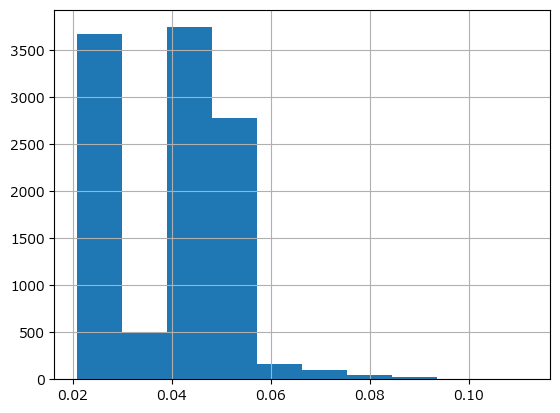

In [49]:
df_submit['target'].hist()